## **Spatial Mapping of Ketamine-Induced Connectivity Changes**

### **Overview**

This final stage of the project translates the numerical results from the graph analysis into a spatial anatomical context. While the previous notebooks established *that* connectivity changes, this notebook identifies *where* these changes occur in the human cortex.

### **Methodology**

**Data Integration:**  
We project the Node Strength and Connectivity Change Scores calculated in the graph analysis stage onto a standard anatomical template.

**Atlas Mapping:**  
Using the Harvard-Oxford Cortical Atlas, we assign statistical scores to 48 distinct bilateral brain regions.

**3D Visualization:**  
We utilize `nilearn` to generate a cortical surface projection (brain map), allowing for an intuitive interpretation of the ketamine-induced "rewiring" of the functional connectome.

In [1]:
!pip install -q nilearn nibabel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 79.1 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from nilearn import datasets, plotting
from nilearn.plotting import find_parcellation_cut_coords

In [5]:
from google.colab import files
uploaded = files.upload()

Saving connections_df.csv to connections_df (1).csv
Saving top_increases_named.csv to top_increases_named.csv


In [61]:
connections_df = pd.read_csv("connections_df.csv")

In [62]:
top_increases_named = pd.read_csv("top_increases_named.csv")

In [9]:
atlas = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")

atlas_maps = atlas.maps
atlas_labels = atlas.labels

region_labels = atlas_labels[1:]

[fetch_atlas_harvard_oxford] Dataset found in /root/nilearn_data/fsl

In [78]:
n_regions = len(region_labels)
full_matrix = np.zeros((n_regions, n_regions))

for _, row in connections_df.iterrows():
    i = int(row["region_1"])
    j = int(row["region_2"])
    val = float(row["delta_connectivity"])

    if 0 <= i < n_regions and 0 <= j < n_regions:
        full_matrix[i, j] = val
        full_matrix[j, i] = val

np.fill_diagonal(full_matrix, 0)

In [85]:
region_scores = np.sum(np.clip(full_matrix, a_min=0, a_max=None), axis=1)

scores_df = pd.DataFrame({
    "region": np.arange(n_regions),
    "region_name": region_labels,
    "score": region_scores
}).sort_values("score", ascending=False)

In [80]:
atlas_data = atlas_maps.get_fdata()
roi_img_data = np.zeros_like(atlas_data, dtype=float)

for roi_idx, score in enumerate(region_scores, start=1):
    roi_img_data[atlas_data == roi_idx] = score

roi_img = nib.Nifti1Image(roi_img_data, atlas_maps.affine)

In [81]:
positive_scores = region_scores[region_scores > 0]

if len(positive_scores) > 0:
    threshold_value = np.percentile(positive_scores, 80)
else:
    threshold_value = 0

print("Threshold:", threshold_value)

Threshold: 7.1583245108


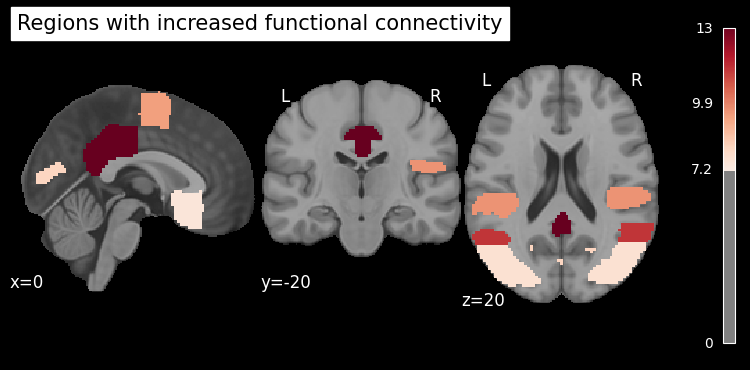

In [83]:
mni_template = datasets.load_mni152_template()

plotting.plot_stat_map(
    roi_img,
    bg_img=mni_template,
    title="Regions with increased functional connectivity",
    display_mode="ortho",
    colorbar=True,
    threshold=threshold_value,
    cut_coords=(0, -20, 20),
    draw_cross=False
)

display.savefig("connectivity_brain_map.png")

plotting.show()

In [84]:
from google.colab import files
files.download("connectivity_brain_map.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#### **Regional involvement in connectivity changes**

The map above shows cortical regions with the strongest increases in functional connectivity.  
Each colored region corresponds to an atlas-defined brain structure from the Harvard–Oxford cortical atlas.

The color scale reflects the aggregate connectivity change score for each region:

- **Darker red**: stronger increase in functional connectivity involvement  
- **Lighter red / peach**: moderate connectivity increase  
- **White / background**: little or no connectivity change

#### **Key regions highlighted in the map**

The following regions show the strongest connectivity changes in the analysis:

1. **Posterior Cingulate Gyrus** — highest connectivity involvement score  
2. **Middle Temporal Gyrus (anterior division)**  
3. **Angular Gyrus**  
4. **Inferior Temporal Gyrus (anterior division)**  
5. **Parietal Opercular Cortex**  
6. **Juxtapositional Lobule Cortex (Supplementary Motor Area)**

# **Summary**

## **Key Regional Involvement in Connectivity Changes**

The analysis identifies six primary cortical structures that exhibit the most significant shifts in functional connectivity following ketamine administration.  
These regions act as network hubs, providing insight into the neural mechanisms underlying ketamine’s rapid antidepressant effects.


### **Posterior Cingulate Gyrus (PCC)**

**Role:**  
The central hub of the Default Mode Network (DMN), associated with self-referential thought and internal dialogue.

**Significance:**  
High connectivity scores in this region suggest that ketamine modulates the rumination circuit, potentially interrupting the cycle of persistent negative self-focused thought commonly observed in depression.


### **Middle Temporal Gyrus (MTG)**

**Role:**  
Involved in social cognition, language processing, and emotional interpretation.

**Significance:**  
Connectivity changes in this region may reflect an improved capacity to process social cues and external emotional stimuli.


### **Angular Gyrus**

**Role:**

Integrates multisensory input and contributes to the formation of a coherent sense of self and perspective.

**Significance:**  
This region is often linked to dissociative experiences associated with ketamine.  
Connectivity changes here may represent a shift in self-perception and perspective relative to the external environment.


### **Inferior Temporal Gyrus (ITG)**

**Role:**  
A key region for high-level visual processing and semantic memory.

**Significance:**  
Alterations in this area suggest a reorganization in how the brain assigns meaning to visual and environmental information.


### **Parietal Opercular Cortex**

**Role:**  
Responsible for somatosensory integration and the processing of physical and emotional pain.

**Significance:**  
Connectivity changes in this region may relate to the reported reduction in the somatic or physical burden of depression, often described by patients as a "physical weight."


### **Juxtapositional Lobule Cortex (formerly Supplementary Motor Area)**

**Role:**  
Essential for planning complex movements and initiating voluntary actions.

**Significance:**  
Modulation of this region may contribute to the reversal of psychomotor retardation, helping restore motivation, energy, and engagement in daily activities.

By mapping these changes, the project demonstrates that ketamine does not just "numb" the brain; it actively reconfigures the functional connectome. The focus on DMN hubs (like the PCC) and motor-integration areas (like the Juxtapositional Lobule) provides a data-driven confirmation of current neurobiological theories regarding rapid-acting antidepressants.